# Fractional Brownian Motion Parameter Estimation Using Variance Aggregation

Consider a time series of $n$, identically distributed samples,</br>

$
\begin{align}
X_1, X_2,X_3,\ldots,X_n
\end{align}
\tag{1}
$

Divide the series into $d$ smaller series of length $m$ where $md=n$.\ and let, $k = 0,1,2,3,\ldots,d-1$ and define the aggregated sum by,

$
\begin{align}
X_k^m &= \frac{1}{m}\left( X_{km+1} + X_{km+2} + \cdots + X_{km+m-1} + X_{km+m} \right) \\
&= \frac{1}{m} \left( X_{km+1} + \cdots + X_{(k+1)m} \right) \\
&= \frac{1}{m} \sum_{i=km+1}^{(k+1)m} X_i
\end{align}
\tag{2}
$

The aggregated mean is given by,

$
\begin{align}
\text{E}[X^m] &= \frac{1}{d}\sum_{i=1}^d X_i^m \\
&= \frac{1}{dm} \sum_{i=1}^d \sum_{j=im+1}^{(k+1)i} X_j \\
&= \frac{1}{n} \sum_{i=1}^n X_i
\end{align}
\tag{3}
$

and the aggregated variance by,

$
\begin{align}
\text{Var}[X^m] = \frac{1}{d} \sum_{i=1}^d\left( X^m_i - \text{E}[X^m] \right)^2
\end{align}
\tag{4}
$

This method makes use of the self similarity of fractional brownian motion. Consider the aggregated process,

$
\begin{align}
X_0^m = \frac{1}{m} \sum_{i=1}^m X_i
\end{align}
\tag{5}
$

From self similarity of fractional brownian motion,

$
\begin{align}
X_{ai} \sim a^H X_i
\end{align}
\tag{6}
$

Since the distribution of the sum of Gaussian random variables is the distribution of the last it follows that,</br> 

$
\begin{align}
X_0^m \sim \frac{1}{m} X_m \sim \frac{m^H}{m} X_1 = m^{H-1} X_1
\end{align}
\tag{7}
$

For fractional brownian noise,

$
\begin{align}
&\text{E}[\Delta Z^H_t] = 0 \\
&\text{Var}[\Delta Z^H_t] = \Delta t^{2H}
\end{align}
\tag{8}
$

$X_1$ is a single increment of brownian motion it follows that,

$
\begin{align}
\text{Var}[X_1] = \Delta t^{2H} = \sigma^2
\end{align}
\tag{9}
$

so,

$
\begin{align}
\text{Var}[X_0^m] = \text{Var}[m^{H-1} X_1] = m^{2(H-1)}\text{Var}[X_1] = \sigma^2 m^{2(H-1)}
\end{align}
\tag{10}
$

From stationarity of it follows that,

$
\begin{align}
\text{Var}[X_k^m] = \sigma^2 m^{2(H-1)}
\end{align}
\tag{11}
$

It follows that $H$ can be determined by using OLS on $\text{Var}[X_k^m]$ as a function of $m$.

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import variance_agg, stack, curve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
Δt = 1.0
npts = 2**10
nagg = 100

def var_agg_comparison(t, fbm_noise, H):
    m_vals = [1, 10, 50]
    title = f"Aggregated Fractional Brownian Noise: Δt={Δt}, H={H}"
    labels = [f"m={m}" for m in m_vals]
    params = [{"m": m} for m in m_vals]
    func = lambda **kwargs: stats.compute_agg(t, fbm_noise, **kwargs)
    t_scan, m_scan = create_parameter_scan(func, *params)
    ylabels = [r"$X^1$", r"$X^{10}$", r"$X^{50}$"]
    stack(m_scan, t_scan, ylim=(-3.5, 3.5), ylabels=ylabels, xlabel=r"$t$", title=title, labels=labels, lw=1)

## Simulation $H=0.8$

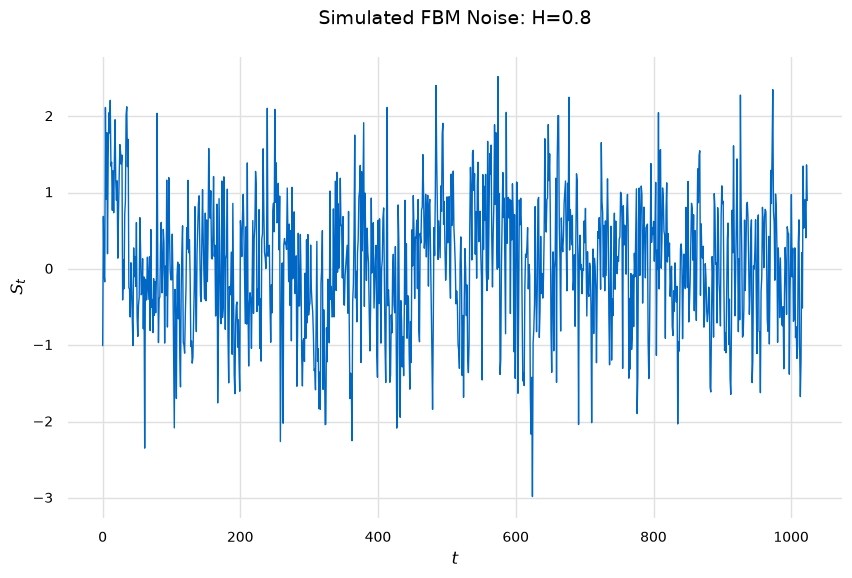

In [3]:
H = 0.8
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

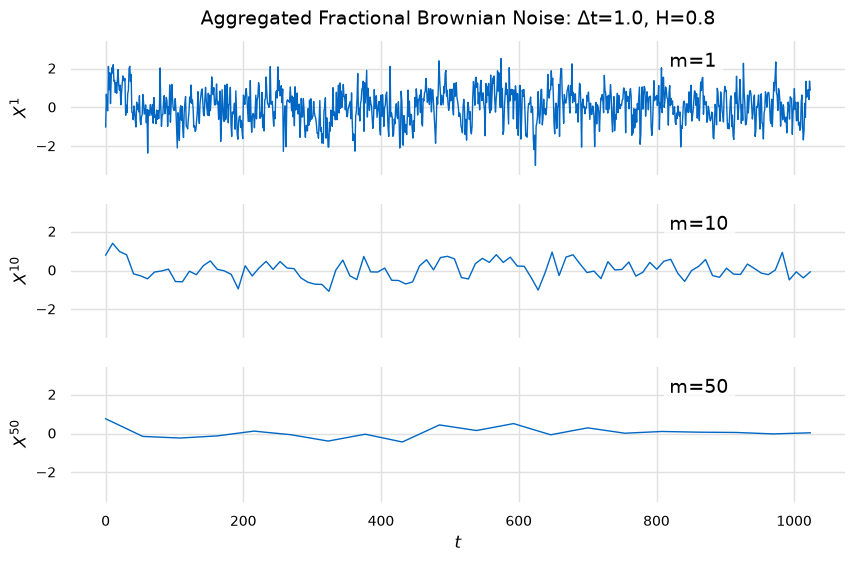

In [4]:
var_agg_comparison(t, fbm_noise, H)

In [5]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [6]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     977.2
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           8.98e-53
Time:                        14:37:23   Log-Likelihood:                 97.699
No. Observations:                 100   AIC:                            -191.4
Df Residuals:                      98   BIC:                            -186.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0777      0.037      2.077      0.040       0.003       0.152
x1            -0.7172      0.023    -31.260      0.000      -0.763      -0.672
==============================================================================
Omnibus:                        3.479   Durbin-Watson:                   0.277
Prob(Omnibus):                  0.176   Jarque-Bera (JB):                2.650
Skew:                          -0.258   Prob(JB):                        0.266
Kurtosis:                       2.392   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.07767592878852066,
      "err": 0.03739467448731935,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "66a676b3-4df9-4de3-9a47-48e3dda41958",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.7172308493774322,
         "err": 0.022944213799204954,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "66a676b3-4df9-4de3-9a47-48e3dda41958",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9088518972151675,
   "param_transforms": [
      {
         "param": {
            "est": 0.6413845753112839,
            "err": 0.011472106899602477,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "or

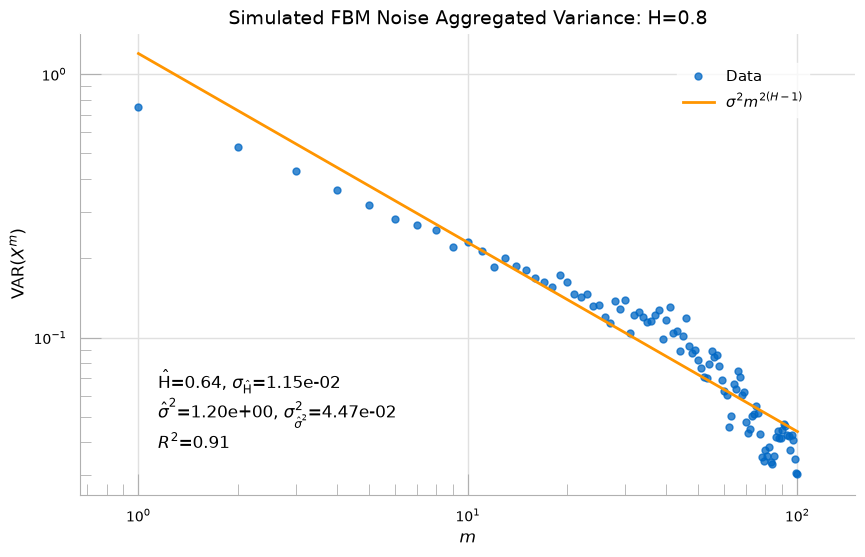

In [8]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.6$

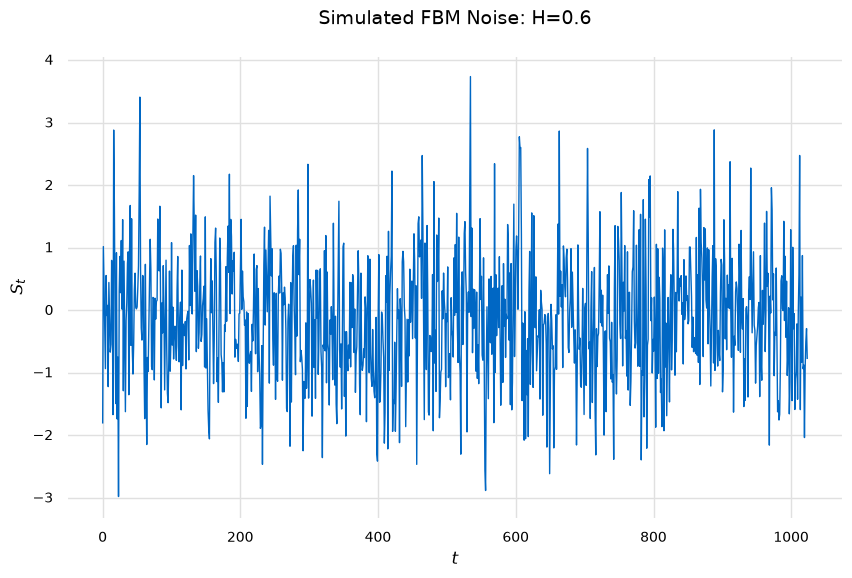

In [9]:
H = 0.6
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

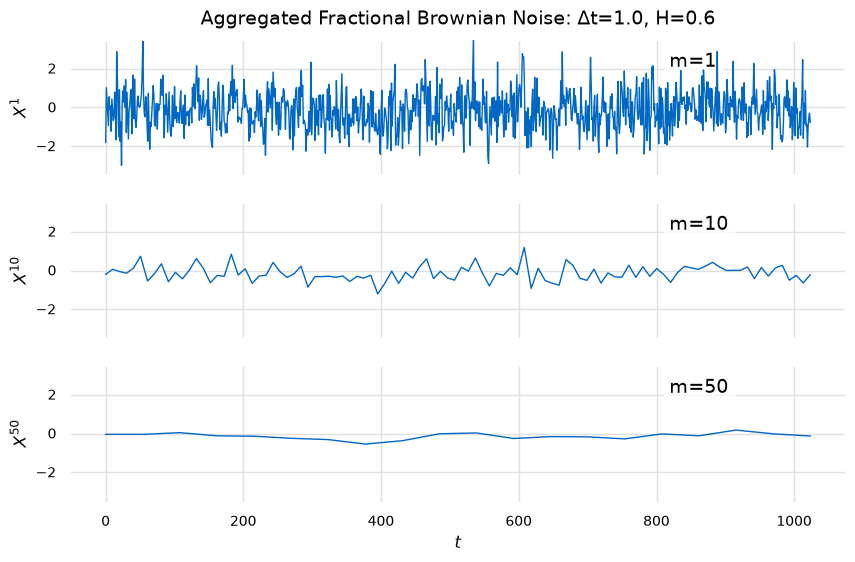

In [10]:
var_agg_comparison(t, fbm_noise, H)

In [11]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [12]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     2334.
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           3.73e-70
Time:                        14:37:24   Log-Likelihood:                 118.28
No. Observations:                 100   AIC:                            -232.6
Df Residuals:                      98   BIC:                            -227.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0592      0.030      1.944      0.055      -0.001       0.120
x1            -0.9022      0.019    -48.312      0.000      -0.939      -0.865
==============================================================================
Omnibus:                        2.908   Durbin-Watson:                   1.331
Prob(Omnibus):                  0.234   Jarque-Bera (JB):                2.266
Skew:                          -0.322   Prob(JB):                        0.322
Kurtosis:                       3.358   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.059183585461743494,
      "err": 0.03043735568993904,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "496ed9cf-8e46-48e8-8e97-5c5290d2d42b",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.9022457633986167,
         "err": 0.018675418518998614,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "496ed9cf-8e46-48e8-8e97-5c5290d2d42b",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9597046744063602,
   "param_transforms": [
      {
         "param": {
            "est": 0.5488771183006916,
            "err": 0.009337709259499307,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "o

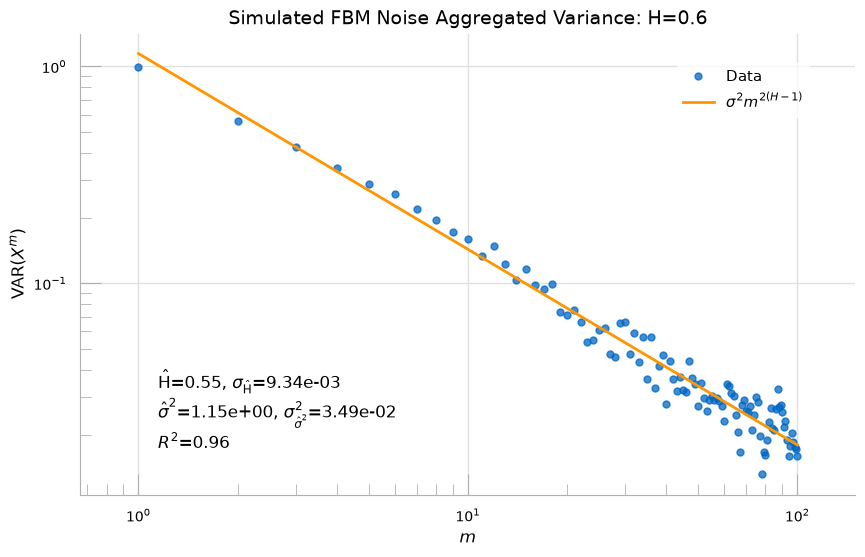

In [14]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.4$

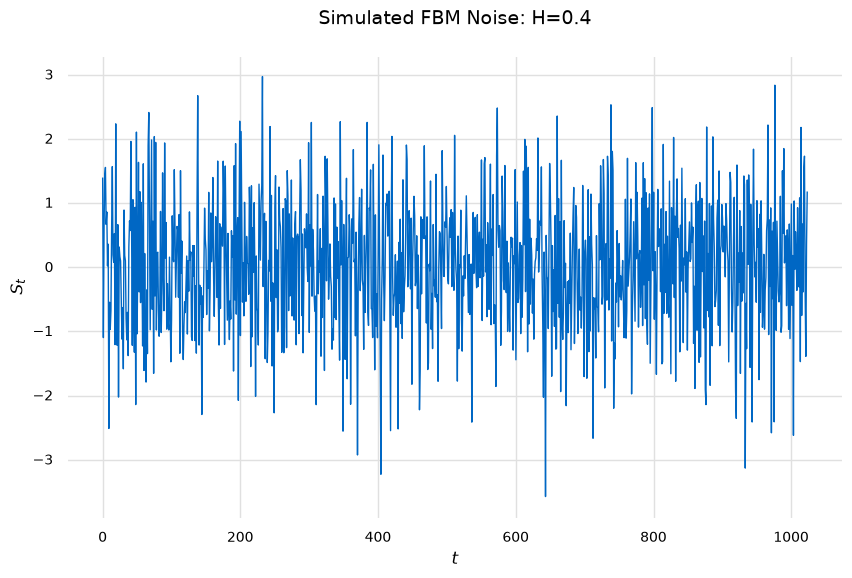

In [15]:
H = 0.4
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

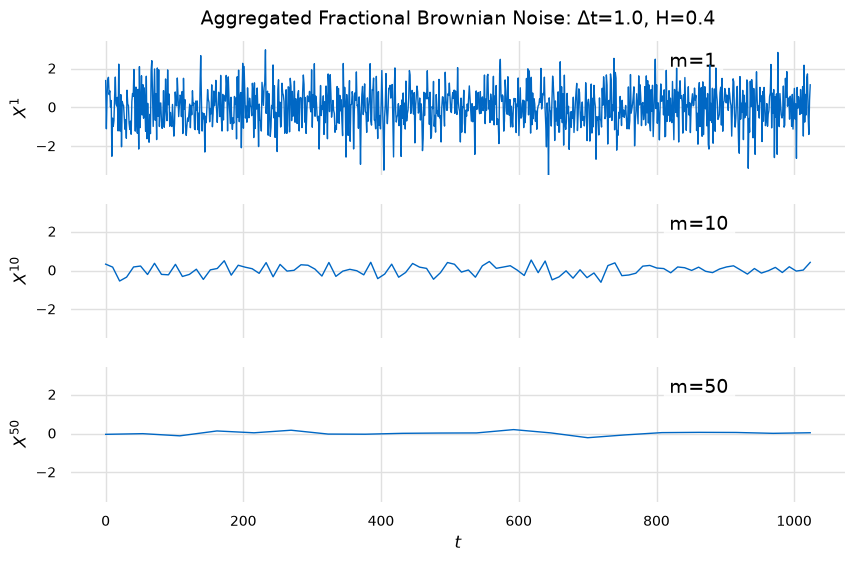

In [16]:
var_agg_comparison(t, fbm_noise, H)

In [17]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [18]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     1800.
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           7.06e-65
Time:                        14:37:24   Log-Likelihood:                 83.894
No. Observations:                 100   AIC:                            -163.8
Df Residuals:                      98   BIC:                            -158.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0599      0.043     -1.394      0.166      -0.145       0.025
x1            -1.1176      0.026    -42.428      0.000      -1.170      -1.065
==============================================================================
Omnibus:                        3.735   Durbin-Watson:                   1.441
Prob(Omnibus):                  0.155   Jarque-Bera (JB):                4.224
Skew:                           0.079   Prob(JB):                        0.121
Kurtosis:                       3.994   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.05986360967840887,
      "err": 0.04293049214037312,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "bb7841f1-81c6-45a4-a32a-0fab7d38d1b7",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -1.1175783128233456,
         "err": 0.026340820014567248,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "bb7841f1-81c6-45a4-a32a-0fab7d38d1b7",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9483695029367064,
   "param_transforms": [
      {
         "param": {
            "est": 0.4412108435883272,
            "err": 0.013170410007283624,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "o

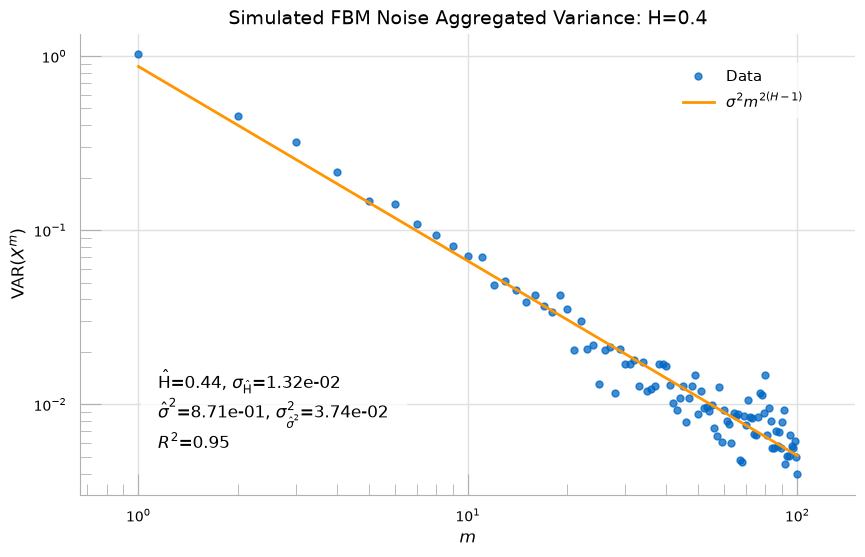

In [20]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.2$

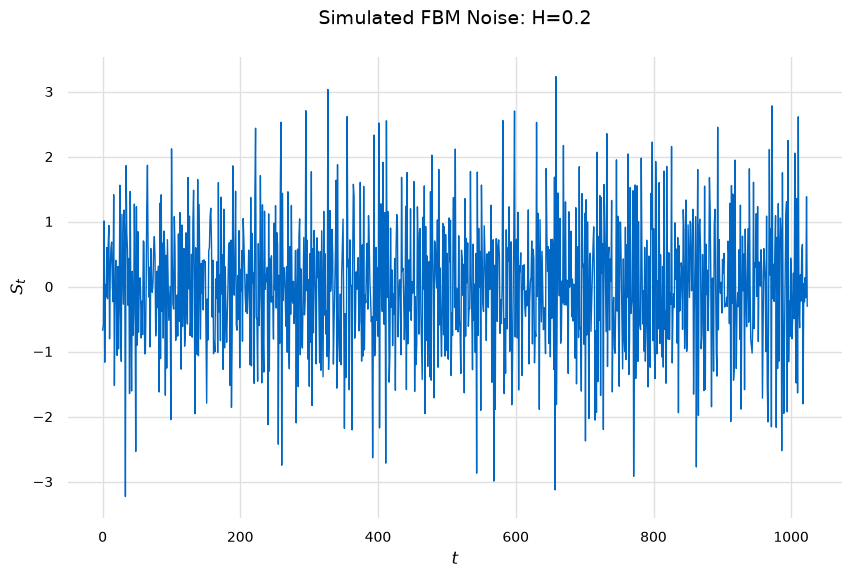

In [21]:
H = 0.2
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

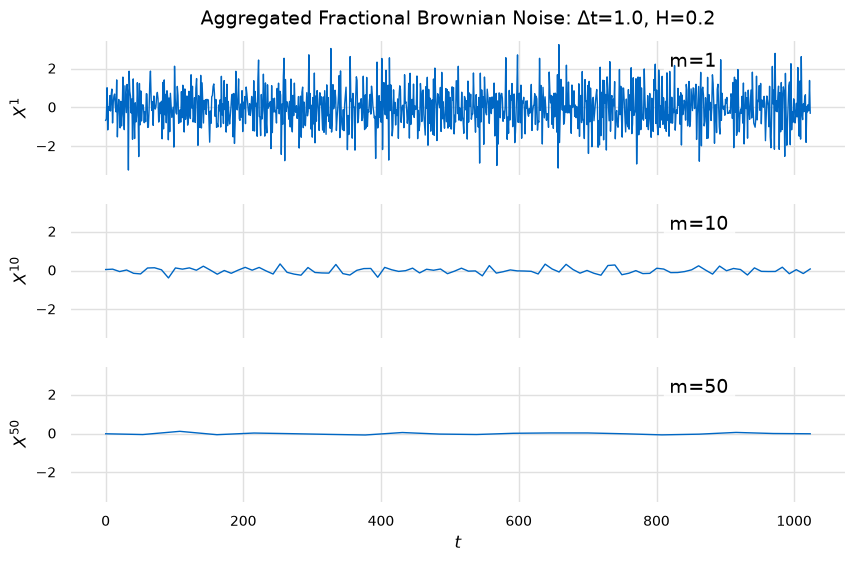

In [22]:
var_agg_comparison(t, fbm_noise, H)

In [23]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [24]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     1901.
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           5.57e-66
Time:                        14:37:24   Log-Likelihood:                 48.825
No. Observations:                 100   AIC:                            -93.65
Df Residuals:                      98   BIC:                            -88.44
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0490      0.061      0.803      0.424      -0.072       0.170
x1            -1.6309      0.037    -43.601      0.000      -1.705      -1.557
==============================================================================
Omnibus:                        8.260   Durbin-Watson:                   1.731
Prob(Omnibus):                  0.016   Jarque-Bera (JB):               10.751
Skew:                          -0.402   Prob(JB):                      0.00463
Kurtosis:                       4.391   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.04896035334840686,
      "err": 0.06096295477592176,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "1d0398a1-cbed-43e7-902d-adaad04c80c9",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -1.6308832320632867,
         "err": 0.03740498045207831,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "1d0398a1-cbed-43e7-902d-adaad04c80c9",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9509759980786296,
   "param_transforms": [
      {
         "param": {
            "est": 0.18455838396835667,
            "err": 0.018702490226039155,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "or

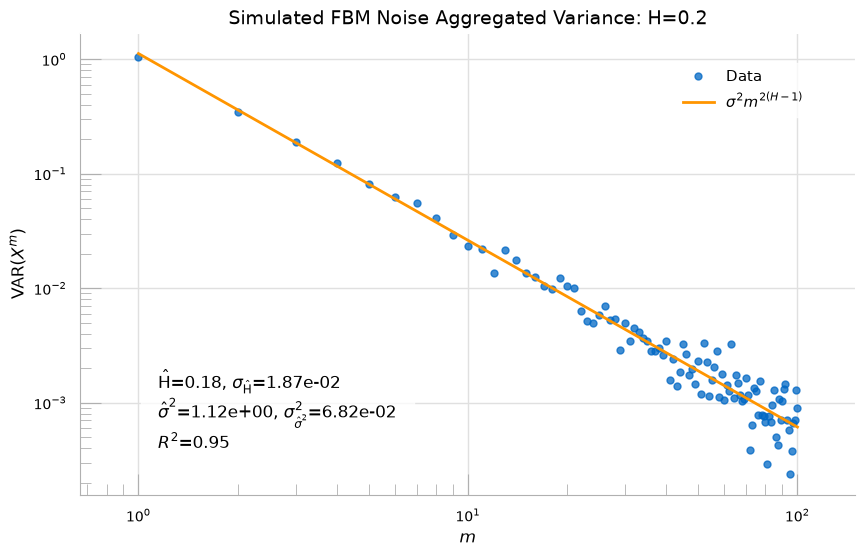

In [26]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")